In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("..\\data\\raw\\student_placement_prediction_dataset_2026.csv")

df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.shape

(100000, 26)

In [5]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [6]:
df.sample(5)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
9709,9710,18,Male,5.29,IT,Tier 3,1,1,1,60.536115,...,77.298454,94.760843,0,41.438727,65.598687,Yes,5.3,2.1,Not Placed,0.00
43083,43084,20,Male,7.92,Mechanical,Tier 3,3,2,2,73.150332,...,77.686878,78.775762,0,31.409244,55.242995,Yes,6.1,7.0,Placed,15.29
71963,71964,22,Male,5.73,CSE,Tier 1,1,1,0,42.159960,...,66.629637,77.946472,0,69.939560,57.543683,Yes,7.0,2.2,Not Placed,0.00
60464,60465,19,Female,7.26,ECE,Tier 1,3,2,1,36.146251,...,78.059794,99.406738,1,58.593567,57.219158,Yes,6.5,2.4,Placed,12.90
19764,19765,20,Male,8.29,Civil,Tier 3,1,3,2,78.370834,...,56.943276,81.477001,1,49.452441,51.666744,Yes,5.7,3.7,Placed,15.04


In [7]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [9]:
df["placement_status"].value_counts()

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

In [10]:
df["placement_status"].value_counts(normalize=True) * 100

placement_status
Placed        54.459
Not Placed    45.541
Name: proportion, dtype: float64

In [11]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [15]:
df.select_dtypes(include="object").columns

C:\Users\Dell\AppData\Local\Temp\ipykernel_15492\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['gender', 'branch', 'college_tier', 'volunteer_experience',
       'placement_status'],
      dtype='str')

In [16]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].unique())


 gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

 branch
<StringArray>
['IT', 'CSE', 'EEE', 'Civil', 'Mechanical', 'ECE']
Length: 6, dtype: str

 college_tier
<StringArray>
['Tier 2', 'Tier 1', 'Tier 3']
Length: 3, dtype: str

 volunteer_experience
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 placement_status
<StringArray>
['Not Placed', 'Placed']
Length: 2, dtype: str


C:\Users\Dell\AppData\Local\Temp\ipykernel_15492\1618711878.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


In [17]:
df.nunique()

student_id                   100000
age                               7
gender                            2
cgpa                            551
branch                            6
college_tier                      3
internships_count                 9
projects_count                   14
certifications_count             12
coding_skill_score            97643
aptitude_score                98859
communication_skill_score     98872
logical_reasoning_score       98730
hackathons_participated           9
github_repos                     16
linkedin_connections            950
mock_interview_score          99352
attendance_percentage         93397
backlogs                          7
extracurricular_score         97660
leadership_score              98473
volunteer_experience              2
sleep_hours                      71
study_hours_per_day              92
placement_status                  2
salary_package_lpa             1047
dtype: int64

In [18]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\Dell\AppData\Local\Temp\ipykernel_15492\1797605437.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['gender', 'branch', 'college_tier', 'volunteer_experience',
       'placement_status'],
      dtype='str')

In [19]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Male      60028
Female    39972
Name: count, dtype: int64

 branch
branch
CSE           34818
IT            19999
ECE           14908
EEE           10177
Mechanical    10077
Civil         10021
Name: count, dtype: int64

 college_tier
college_tier
Tier 2    49955
Tier 3    29884
Tier 1    20161
Name: count, dtype: int64

 volunteer_experience
volunteer_experience
No     59963
Yes    40037
Name: count, dtype: int64

 placement_status
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,100000.0,50000.500000,28867.657797,1.0,25000.750000,50000.500000,75000.250000,100000.00
age,100000.0,21.005740,1.999562,18.0,19.000000,21.000000,23.000000,24.00
cgpa,100000.0,7.496890,0.992834,4.5,6.820000,7.500000,8.180000,10.00
internships_count,100000.0,1.502230,1.225280,0.0,1.000000,1.000000,2.000000,8.00
projects_count,100000.0,3.001860,1.731764,0.0,2.000000,3.000000,4.000000,13.00
certifications_count,100000.0,2.005150,1.416553,0.0,1.000000,2.000000,3.000000,11.00
coding_skill_score,100000.0,69.825326,14.694618,20.0,59.807945,70.006250,80.058762,100.00
aptitude_score,100000.0,64.988108,14.844093,20.0,54.894600,65.011394,75.079266,100.00
communication_skill_score,100000.0,67.960744,13.846636,20.0,58.587535,67.973221,77.503749,100.00
logical_reasoning_score,100000.0,65.931696,14.826790,20.0,55.940547,66.003829,76.113705,100.00


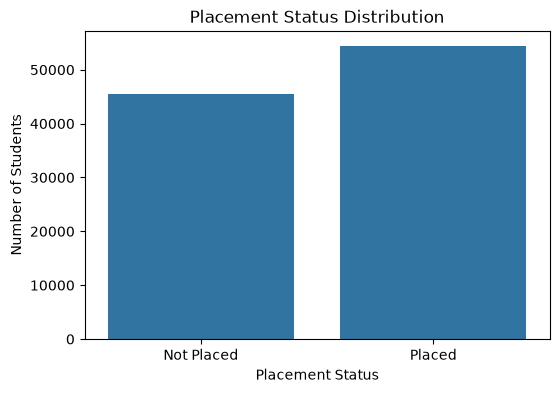

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="placement_status")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

In [24]:
placement_percentage = (
    df["placement_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

placement_percentage

placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64

In [25]:
df.nunique()

student_id                   100000
age                               7
gender                            2
cgpa                            551
branch                            6
college_tier                      3
internships_count                 9
projects_count                   14
certifications_count             12
coding_skill_score            97643
aptitude_score                98859
communication_skill_score     98872
logical_reasoning_score       98730
hackathons_participated           9
github_repos                     16
linkedin_connections            950
mock_interview_score          99352
attendance_percentage         93397
backlogs                          7
extracurricular_score         97660
leadership_score              98473
volunteer_experience              2
sleep_hours                      71
study_hours_per_day              92
placement_status                  2
salary_package_lpa             1047
dtype: int64

In [26]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

C:\Users\Dell\AppData\Local\Temp\ipykernel_15492\277414104.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['gender', 'branch', 'college_tier', 'volunteer_experience',
       'placement_status'],
      dtype='str')

In [27]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Male      60028
Female    39972
Name: count, dtype: int64

 branch
branch
CSE           34818
IT            19999
ECE           14908
EEE           10177
Mechanical    10077
Civil         10021
Name: count, dtype: int64

 college_tier
college_tier
Tier 2    49955
Tier 3    29884
Tier 1    20161
Name: count, dtype: int64

 volunteer_experience
volunteer_experience
No     59963
Yes    40037
Name: count, dtype: int64

 placement_status
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,100000.0,50000.500000,28867.657797,1.0,25000.750000,50000.500000,75000.250000,100000.00
age,100000.0,21.005740,1.999562,18.0,19.000000,21.000000,23.000000,24.00
cgpa,100000.0,7.496890,0.992834,4.5,6.820000,7.500000,8.180000,10.00
internships_count,100000.0,1.502230,1.225280,0.0,1.000000,1.000000,2.000000,8.00
projects_count,100000.0,3.001860,1.731764,0.0,2.000000,3.000000,4.000000,13.00
certifications_count,100000.0,2.005150,1.416553,0.0,1.000000,2.000000,3.000000,11.00
coding_skill_score,100000.0,69.825326,14.694618,20.0,59.807945,70.006250,80.058762,100.00
aptitude_score,100000.0,64.988108,14.844093,20.0,54.894600,65.011394,75.079266,100.00
communication_skill_score,100000.0,67.960744,13.846636,20.0,58.587535,67.973221,77.503749,100.00
logical_reasoning_score,100000.0,65.931696,14.826790,20.0,55.940547,66.003829,76.113705,100.00


In [29]:

df_clean = df.copy()

In [30]:
df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

In [31]:
df_clean.shape

(100000, 24)

In [32]:
df_clean.columns

Index(['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count',
       'projects_count', 'certifications_count', 'coding_skill_score',
       'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status'],
      dtype='str')

In [33]:
df_clean.isnull().sum().sum()

np.int64(0)

In [34]:
df_clean.duplicated().sum()

np.int64(0)

In [35]:
df_clean.dtypes

age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience             str
sleep_hours                  float64
study_hours_per_day          float64
placement_status                 str
dtype: object

In [36]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,21.005740,1.999562,18.0,19.000000,21.000000,23.000000,24.0
cgpa,100000.0,7.496890,0.992834,4.5,6.820000,7.500000,8.180000,10.0
internships_count,100000.0,1.502230,1.225280,0.0,1.000000,1.000000,2.000000,8.0
projects_count,100000.0,3.001860,1.731764,0.0,2.000000,3.000000,4.000000,13.0
certifications_count,100000.0,2.005150,1.416553,0.0,1.000000,2.000000,3.000000,11.0
coding_skill_score,100000.0,69.825326,14.694618,20.0,59.807945,70.006250,80.058762,100.0
aptitude_score,100000.0,64.988108,14.844093,20.0,54.894600,65.011394,75.079266,100.0
communication_skill_score,100000.0,67.960744,13.846636,20.0,58.587535,67.973221,77.503749,100.0
logical_reasoning_score,100000.0,65.931696,14.826790,20.0,55.940547,66.003829,76.113705,100.0
hackathons_participated,100000.0,1.000690,0.997908,0.0,0.000000,1.000000,2.000000,8.0


In [37]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove columns that should not be used for prediction
df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

# Check dimensions
print("Shape:", df_clean.shape)

# Check missing values
print("Total missing values:", df_clean.isnull().sum().sum())

# Check duplicate rows
print("Duplicate rows:", df_clean.duplicated().sum())

Shape: (100000, 24)
Total missing values: 0
Duplicate rows: 0
